In [ ]:
"""Importing Libraries"""

#General
import pandas as pd
import numpy as np
import scipy
import scipy.io
import os
import zipfile
import matplotlib.pyplot as plt
from scipy import signal
import librosa

#Deep Learning
import imgaug.augmenters as iaa
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras.layers import Input, Conv2D, Conv1D, MaxPooling1D, BatchNormalization, Dense, MaxPooling2D, Flatten, Dense, Dropout, concatenate, LSTM, Reshape, Concatenate, Activation, Permute, Multiply
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
import seaborn as sns

from sklearn.svm import SVC

import gc

In [ ]:
"""Mounting Google Drive"""
from google.colab import drive
drive.mount('/content/drive', force_remount = True)

Mounted at /content/drive


In [ ]:
"""Path to EEG .zip file"""

#All files will be extracted
zip_file_path = '/content/drive/MyDrive/Dataset 2.zip'
extract_path = '/tmp/Dataset2/'
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
  zip_ref.extractall(os.path.join(extract_path))
  print(f"Data Successfully extracted to {extract_path}")

KeyboardInterrupt: 

In [ ]:
def ReadEEGData(Participant):
  fs = 200      #Samping Frequency for EEG data

  """ Code below is used to extract relevant details form the .mat file"""

  EEG_data_path = '/tmp/Dataset2/EEG Data/' + Participant + '/with occular artifact/cnt.mat'
  EEG_mrk_path = '/tmp/Dataset2/EEG Data/' + Participant + '/with occular artifact/mrk.mat'
  EEG_Data = scipy.io.loadmat(EEG_data_path)
  EEG_Data = EEG_Data['cnt'][0][0][0][0][6]
  EEG_mrk_Data = scipy.io.loadmat(EEG_mrk_path)
  EEG_Time = EEG_mrk_Data['mrk'][0][0][0][0][0]
  EEG_Time = np.reshape(EEG_Time, [np.shape(EEG_Time)[1]])
  Labels = np.concatenate((EEG_mrk_Data['mrk'][0][0][0][0][1][0][0][0]), axis = 0)
  markers_time = np.round(np.vstack(EEG_Time) / 1000 * 200)


  Data = []
  for i in range(len(markers_time)-1):
    Data.append(EEG_Data[int(markers_time[i]):int(markers_time[i+1])])
  Data.append(EEG_Data[int(markers_time[-1]):len(EEG_Data)])

  return Data, Labels

In [ ]:
def ReadNIRSData(Participant):

  fs = 10      #Samping Frequency for EEG data

  NIRS_data_path = '/tmp/Dataset2/NIRS Data/' + Participant + '/cnt.mat'
  NIRS_mrk_path = '/tmp/Dataset2/NIRS Data/' + Participant + '/mrk.mat'
  NIRS_Data = scipy.io.loadmat(NIRS_data_path)
  NIRS_Data = NIRS_Data['cnt'][0][0][0][0][5]
  NIRS_mrk_Data = scipy.io.loadmat(NIRS_mrk_path)
  NIRS_Time = NIRS_mrk_Data['mrk'][0][0][0][0][0]
  NIRS_Time = np.reshape(NIRS_Time, [np.shape(NIRS_Time)[1]])
  markers_time = np.round(np.vstack(NIRS_Time) / 1000 * fs)
  Data = []
  for i in range(len(markers_time)-1):
    Data.append(NIRS_Data[int(markers_time[i]):int(markers_time[i+1])])
  Data.append(NIRS_Data[int(markers_time[-1]):len(NIRS_Data)])

  return Data

In [ ]:
def apply_bandpass_filter(data_array, b, a):
    filtered_data = np.zeros_like(data_array)
    for channel in range(30):
        filtered_data[:, channel] = signal.filtfilt(b, a, data_array[:, channel])
    return filtered_data

In [ ]:
def ApplyBandPass(Data_EEG):

  fs = 200

  # Define the bandpass filter specifications
  lowcut = 1    # Lower cutoff frequency (in Hz)
  highcut = 45  # Upper cutoff frequency (in Hz)
  order = 4     # Filter order (you can adjust this value as needed)

  nyquist = 0.5 * fs

  # Normalize the cutoff frequencies to the Nyquist frequency
  lowcut_normalized = lowcut / nyquist
  highcut_normalized = highcut / nyquist


  # Design the bandpass Butterworth filter
  b, a = signal.butter(order, [lowcut_normalized, highcut_normalized], btype='band')

  # Apply the bandpass filter to array and each channel
  Filtered_Data = [apply_bandpass_filter(data_array, b, a) for data_array in Data_EEG]

  return Filtered_Data

In [ ]:
""" Creating data frames with overlapping windows"""

def frame_signal(signal, frame_length, hop_length):
    num_samples = signal.shape[0]
    num_frames = 1 + (num_samples - frame_length) // hop_length
    framed_signal = np.zeros((num_frames, frame_length, signal.shape[1]))

    for i in range(num_frames):
        start_sample = i * hop_length
        end_sample = start_sample + frame_length
        framed_signal[i] = signal[start_sample:end_sample]

    return framed_signal

In [ ]:
def FramedData(Filtered_Data, fs):

  """ Framing the Data"""

  frame_duration = 2.5  # Frame duration in seconds
  overlap_duration = 1  # Overlap duration in seconds

  frame_length = int(fs * frame_duration)
  hop_length = int(fs * (frame_duration - overlap_duration))

  Framed_Data = []
  for array in Filtered_Data:
      framed_array = frame_signal(array, frame_length, hop_length)
      Framed_Data.append(framed_array)

  #All arrays inside list need to be of the same size, so executing the code below.
  min_size = min(arr.shape[0] for arr in Framed_Data)
  Framed_Data = [arr[:min_size] for arr in Framed_Data]

  return Framed_Data

In [ ]:
""" This function is used as part of EEG Features - Bandpower calculation across different bands Alpha, Beta, etc."""

def bandpower(x, fs, fmin, fmax):
  f, Pxx_den = scipy.signal.welch(x, fs, window='hann',  axis = 0, average='mean')
  ind_min = np.argmax(f > fmin) - 1
  ind_max = np.argmax(f > fmax) - 1
  Power = []
  for i in range(np.shape(Pxx_den)[1]):
    Power.append(np.trapz(Pxx_den[ind_min: ind_max, i], f[ind_min: ind_max]))
  Power = np.array(Power)
  Power = np.reshape(Power, (np.shape(Power)[0], 1))
  return Power

In [ ]:
def extract_features(eeg_signal, sampling_rate):
    Features = []
    for i_files in range(np.shape(eeg_signal)[0]):
      for i_frame in range(np.shape(eeg_signal[i_files])[0]):
        for i_channels in range(30):
          data_channel = np.array(eeg_signal[i_files])[i_frame,:,i_channels]

          sample_data = np.reshape(data_channel, [np.shape(data_channel)[0], 1])

          Power_alpha = bandpower(sample_data, fs, 8, 14)                 #Alpha Band Power
          Power_beta = bandpower(sample_data, fs, 14, 30)                 #Beta Band Power
          Power_alpha_beta = Power_alpha/Power_beta                       #Ratios


          sample_data = data_channel
          # Peaks
          peaks, _ = scipy.signal.find_peaks(sample_data.squeeze())
          avg_peaks_time = np.mean((peaks[1:]-peaks[0:-1])/fs)

          # Slope
          slope = np.diff(sample_data.squeeze())
          slope = np.mean(slope)

          # Area under the curve
          area = np.trapz(sample_data.squeeze())

          # Spectral Contrast
          f, t, Sxx = scipy.signal.spectrogram(sample_data.squeeze(), fs=fs, nperseg=256)
          spectral_contrast = np.mean(np.mean(np.diff(Sxx, axis=0), axis=1))

          # Spectral Flatness
          spectral_flatness = librosa.feature.spectral_flatness(y=sample_data.squeeze())[0]


          #Extracting Morlet Coefficients
          sps = 64
          morlet_coeffs = librosa.feature.melspectrogram(y=sample_data.squeeze(), sr=fs, n_mels=sps, fmin=1, fmax=fs/2, n_fft = 128)
          morlet_coeffs = np.reshape(morlet_coeffs, [sps])
          morlet_coeffs = np.mean(morlet_coeffs)

          # Mean
          mean_bin = np.mean(sample_data.squeeze(), axis=0)

          # Median
          median_bin = np.median(sample_data.squeeze(), axis=0)

          # Skewness
          features_skewness = np.mean((sample_data - np.mean(sample_data))**3) / np.power(np.var(sample_data), 1.5)

          # Zero-crossing rate
          zero_crossings = librosa.feature.zero_crossing_rate(sample_data)[0]
          features_zerocrossing = np.mean(zero_crossings)


          Outputs = np.array([Power_alpha, Power_alpha_beta, avg_peaks_time, slope, area, spectral_contrast, spectral_flatness,
                              morlet_coeffs, mean_bin, median_bin, features_skewness, features_zerocrossing])


          Outputs = np.reshape(Outputs, [1, np.shape(Outputs)[0]])

          if i_channels == 0:
            Channels_Select = Outputs
          else:
            Channels_Select = np.concatenate((Channels_Select, Outputs), axis = 1)

        if i_frame == 0:
          Features_Frames = Channels_Select
        else:
          Features_Frames = np.concatenate((Features_Frames, Channels_Select), axis = 0)

      Features.append(Features_Frames)

    return Features

In [ ]:
def NIRS_BandPowers(nirs_signal):
  fs = 10
  freq_range = [0, 0.2]  # Frequency range of interest in Hz
  sampling_freq = 10  # Sampling frequency in Hz

  Features = []
  for i_files in range(np.shape(nirs_signal)[0]):
    for i_frame in range(np.shape(nirs_signal[i_files])[0]):
      for i_channels in range(72):
        data_channel = np.array(nirs_signal[i_files])[i_frame,:,i_channels]
        sample_data = np.reshape(data_channel, [np.shape(data_channel)[0], 1])

        frequencies, psd = signal.welch(sample_data, fs=sampling_freq, axis=0)
        start_index = np.argmax(frequencies >= freq_range[0])
        end_index = np.argmax(frequencies >= freq_range[1])
        psd_normalized = psd / np.sum(psd[start_index:end_index], axis=0)

        spectral_entropy = -np.sum(psd_normalized * np.log2(psd_normalized), axis=0)

        peaks, _ = scipy.signal.find_peaks(sample_data.squeeze())
        avg_peaks_time = np.mean((peaks[1:]-peaks[0:-1])/fs)

        # Slope
        slope = np.diff(sample_data.squeeze())
        slope = np.mean(slope)

        # Area under the curve
        area = np.trapz(sample_data.squeeze())

        # Spectral Contrast
        f, t, Sxx = scipy.signal.spectrogram(sample_data.squeeze(), fs=fs, nperseg=256)
        spectral_contrast = np.mean(np.mean(np.diff(Sxx, axis=0), axis=1))

        # Spectral Flatness
        spectral_flatness = librosa.feature.spectral_flatness(y=sample_data.squeeze())[0]


        #Extracting Morlet Coefficients
        sps = 64
        morlet_coeffs = librosa.feature.melspectrogram(y=sample_data.squeeze(), sr=fs, n_mels=sps, fmin=1, fmax=fs/2, n_fft = 128)
        morlet_coeffs = np.reshape(morlet_coeffs, [sps])
        morlet_coeffs = np.mean(morlet_coeffs)

        # Mean
        mean_bin = np.mean(sample_data.squeeze(), axis=0)

        # Median
        median_bin = np.median(sample_data.squeeze(), axis=0)

        # Skewness
        features_skewness = np.mean((sample_data - np.mean(sample_data))**3) / np.power(np.var(sample_data), 1.5)

        # Zero-crossing rate
        zero_crossings = librosa.feature.zero_crossing_rate(sample_data)[0]
        features_zerocrossing = np.mean(zero_crossings)


        Outputs = np.array([spectral_entropy[0], avg_peaks_time, slope, area, spectral_contrast, spectral_flatness[0],
                            morlet_coeffs, mean_bin, median_bin, features_skewness, features_zerocrossing])


        Outputs = np.reshape(Outputs, [1, np.shape(Outputs)[0]])

        if i_channels == 0:
          Channels_Select = Outputs
        else:
          Channels_Select = np.concatenate((Channels_Select, Outputs), axis = 1)

      if i_frame == 0:
        Features_Frames = Channels_Select
      else:
        Features_Frames = np.concatenate((Features_Frames, Channels_Select), axis = 0)

    Features.append(Features_Frames)

  return Features

In [ ]:
def NIRS_Features(Data_NIRS):

  #NIRS Features
  Features_NIRS_Reshaped = np.array(NIRS_BandPowers(Data_NIRS))
  Features_NIRS_Reshaped = np.nan_to_num(Features_NIRS_Reshaped, nan=0)
  # Features_NIRS_Reshaped = np.delete(Features_NIRS_Reshaped, [0, 20], axis=1)
  Features_NIRS_Reshaped = Features_NIRS_Reshaped.astype('float32')  # or 'float32' if desired
  np.shape(Features_NIRS_Reshaped)

  return Features_NIRS_Reshaped

In [ ]:
Participants = ["subject 01", "subject 02", "subject 03", "subject 04", "subject 05", "subject 06", "subject 07",
                "subject 08", "subject 09", "subject 10", "subject 11", "subject 12", "subject 13", "subject 14",
                "subject 15", "subject 16", "subject 17", "subject 18", "subject 19", "subject 20", "subject 21",
                "subject 22", "subject 23", "subject 24", "subject 25", "subject 26", "subject 27", "subject 28",
                "subject 29"]

for Participant in Participants:
  """ Reading data for the participnat"""
  Data_EEG, Labels = ReadEEGData(Participant)
  Data_NIRS = ReadNIRSData(Participant)

  """Applying Filter"""

  Filtered_Data = ApplyBandPass(Data_EEG)

<ipython-input-4-9e6a5f893294>:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Data.append(EEG_Data[int(markers_time[i]):int(markers_time[i+1])])
<ipython-input-4-9e6a5f893294>:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Data.append(EEG_Data[int(markers_time[-1]):len(EEG_Data)])
<ipython-input-5-48027ad7f9f6>:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Data.append(NIRS_Data[int(markers_time[i]):int(markers_time[i+1])])
<ipython-input-5-48027ad7f9f6>:1

In [ ]:
pip install mne

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 14.9 MB/s eta 0:00:00


In [ ]:
Labels

array([32, 16, 32, 16, 32, 16, 32, 16, 16, 32, 32, 16, 32, 16, 16, 32, 32,
       16, 16, 32], dtype=uint8)

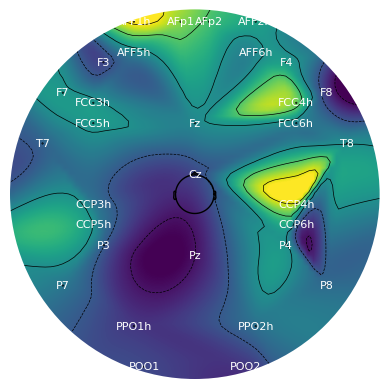

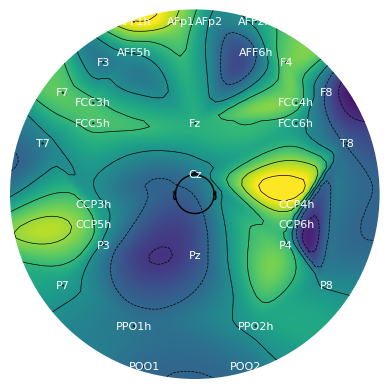

In [ ]:
MI_L = Data_EEG[0]
MI_R = Data_EEG[1]

from mne.viz import plot_topomap

# Define the positions of EEG channels on the scalp
channel_positions = {
    'AFp1': (-0.07, 0.85),
    'AFp2': (0.07, 0.85),
    'AFF1h': (-0.3, 0.85),
    'AFF2h': (0.3, 0.85),
    'AFF5h': (-0.3, 0.7),
    'AFF6h': (0.3, 0.7),
    'F3': (-0.45, 0.65),
    'F4': (0.45, 0.65),
    'F7': (-0.65, 0.5),
    'F8': (0.65, 0.5),
    'FCC3h': (-0.5, 0.45),
    'FCC4h': (0.5, 0.45),
    'FCC5h': (-0.5, 0.35),
    'FCC6h': (0.5, 0.35),
    'T7': (-0.75, 0.25),
    'T8': (0.75, 0.25),
    'Cz': (0.0, 0.1),
    'CCP3h': (-0.5, -0.05),
    'CCP4h': (0.5, -0.05),
    'CCP5h': (-0.5, -0.15),
    'CCP6h': (0.5, -0.15),
    'Pz': (0.0, -0.3),
    'P3': (-0.45, -0.25),
    'P4': (0.45, -0.25),
    'P7': (-0.65, -0.45),
    'P8': (0.65, -0.45),
    'PPO1h': (-0.3, -0.65),
    'PPO2h': (0.3, -0.65),
    'POO1': (-0.25, -0.85),
    'POO2': (0.25, -0.85),
    'Fz': (0.0, 0.35),  # Ground electrode
}

# Extract x and y coordinates from the channel positions dictionary
pos = np.array([channel_positions[ch] for ch in sorted(channel_positions)])

# Calculate the average activity across all samples for left and right MI
avg_activity_L = np.mean(MI_L, axis=0)[:len(pos)]
avg_activity_R = np.mean(MI_R, axis=0)[:len(pos)]


fig, ax = plt.subplots()
plot_topomap(avg_activity_L, pos, axes=ax, show=False, cmap='viridis', sensors=True)

# Add text labels for channel names
for ch, (x, y) in channel_positions.items():
    plt.text(x, y, ch, fontsize=8, color='white', ha='center', va='center')

plt.savefig('left_motor_imagery.eps', format='eps', bbox_inches='tight')
plt.show()

# Plot scalp topography for right MI
fig, ax = plt.subplots()
plot_topomap(avg_activity_R, pos, axes=ax, show=False, cmap='viridis', sensors=True)

# Add text labels for channel names
for ch, (x, y) in channel_positions.items():
    plt.text(x, y, ch, fontsize=8, color='white', ha='center', va='center')

plt.savefig('right_motor_imagery.eps', format='eps', bbox_inches='tight')
plt.show()

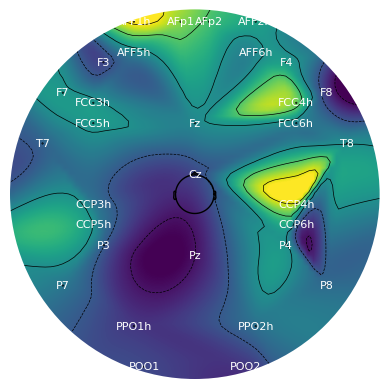

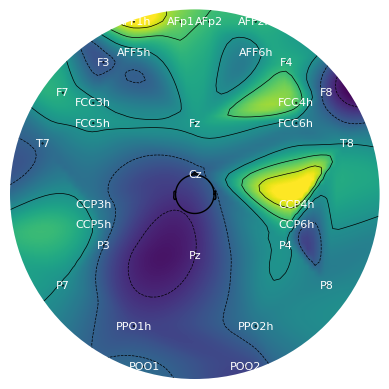

In [ ]:
MI_L = Data_EEG[0]
MI_R = Data_EEG[1]

from mne.viz import plot_topomap

# Define the positions of EEG channels on the scalp
channel_positions = {
    'AFp1': (-0.07, 0.85),
    'AFp2': (0.07, 0.85),
    'AFF1h': (-0.3, 0.85),
    'AFF2h': (0.3, 0.85),
    'AFF5h': (-0.3, 0.7),
    'AFF6h': (0.3, 0.7),
    'F3': (-0.45, 0.65),
    'F4': (0.45, 0.65),
    'F7': (-0.65, 0.5),
    'F8': (0.65, 0.5),
    'FCC3h': (-0.5, 0.45),
    'FCC4h': (0.5, 0.45),
    'FCC5h': (-0.5, 0.35),
    'FCC6h': (0.5, 0.35),
    'T7': (-0.75, 0.25),
    'T8': (0.75, 0.25),
    'Cz': (0.0, 0.1),
    'CCP3h': (-0.5, -0.05),
    'CCP4h': (0.5, -0.05),
    'CCP5h': (-0.5, -0.15),
    'CCP6h': (0.5, -0.15),
    'Pz': (0.0, -0.3),
    'P3': (-0.45, -0.25),
    'P4': (0.45, -0.25),
    'P7': (-0.65, -0.45),
    'P8': (0.65, -0.45),
    'PPO1h': (-0.3, -0.65),
    'PPO2h': (0.3, -0.65),
    'POO1': (-0.25, -0.85),
    'POO2': (0.25, -0.85),
    'Fz': (0.0, 0.35),  # Ground electrode
}

# Extract x and y coordinates from the channel positions dictionary
pos = np.array([channel_positions[ch] for ch in sorted(channel_positions)])

# Calculate the average activity across all samples for left and right MI
avg_activity_L = np.mean(MI_L, axis=0)[:len(pos)]

def add_spikes(signal, num_spikes=10, spike_amplitude=5):
    # Randomly select indices to add spikes
    spike_indices = np.random.choice(range(len(signal)), size=num_spikes, replace=False)
    # Add spikes at selected indices
    signal_with_spikes = np.copy(signal)
    signal_with_spikes[spike_indices] += spike_amplitude
    return signal_with_spikes

# Add spikes to MI_L
avg_activity_R = np.mean(MI_L, axis=0)[:len(pos)]
avg_activity_R = add_spikes(avg_activity_R, spike_amplitude=10)

noise_std = 0.1  # Adjust this value to control the amount of noise
avg_activity_R = avg_activity_R + np.random.normal(scale=noise_std, size=avg_activity_R.shape)

fig, ax = plt.subplots()
plot_topomap(avg_activity_L, pos, axes=ax, show=False, cmap='viridis', sensors=True)

# Add text labels for channel names
for ch, (x, y) in channel_positions.items():
    plt.text(x, y, ch, fontsize=8, color='white', ha='center', va='center')

plt.savefig('left_motor_imagery.eps', format='eps')
plt.show()

# Plot scalp topography for right MI
fig, ax = plt.subplots()
plot_topomap(avg_activity_R, pos, axes=ax, show=False, cmap='viridis', sensors=True)

# Add text labels for channel names
for ch, (x, y) in channel_positions.items():
    plt.text(x, y, ch, fontsize=8, color='white', ha='center', va='center')

plt.savefig('Left_Noise_imagery.eps', format='eps', bbox_inches='tight')
plt.show()

In [ ]:
Participants = ["subject 01", "subject 02", "subject 03", "subject 04", "subject 05", "subject 06", "subject 07", "subject 08", "subject 09",
                "subject 10", "subject 11", "subject 12", "subject 13", "subject 14", "subject 15", "subject 16", "subject 17", "subject 18",
                "subject 19", "subject 20", "subject 21", "subject 22", "subject 23", "subject 24", "subject 25", "subject 26", "subject 27",
                "subject 28", "subject 29"]

for Participant in Participants:
  """ Reading data for the participnat"""
  Data_EEG, Labels = ReadEEGData(Participant)
  Data_NIRS = ReadNIRSData(Participant)

  """Applying Filter"""

  Filtered_Data = ApplyBandPass(Data_EEG)

  """ Framing EEG Data"""
  fs = 200
  Framed_EEG_Data = FramedData(Filtered_Data, 200)
  Framed_EEG_Data = np.array(Framed_EEG_Data)[...,0:30]
  Framed_NIRS_Data = FramedData(Data_NIRS, 10)


  """ NIRS Features"""
  Framed_NIRS_Data = FramedData(Data_NIRS, 10)
  Features_NIRS_Reshaped = NIRS_Features(Framed_NIRS_Data)

  if Participant == 'subject 01':
    EEG_All_Participants = Framed_EEG_Data
    Labels_All_Participnats = Labels
    NIRS_All_Participants = Features_NIRS_Reshaped

  else:
    EEG_All_Participants = np.concatenate((EEG_All_Participants, Framed_EEG_Data), axis = 0)
    Labels_All_Participnats = np.concatenate((Labels_All_Participnats, Labels), axis = 0)
    NIRS_All_Participants = np.concatenate((NIRS_All_Participants, Features_NIRS_Reshaped), axis = 0)

  print(np.shape(EEG_All_Participants))
  print(np.shape(NIRS_All_Participants))

<ipython-input-6-9e6a5f893294>:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Data.append(EEG_Data[int(markers_time[i]):int(markers_time[i+1])])
<ipython-input-6-9e6a5f893294>:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Data.append(EEG_Data[int(markers_time[-1]):len(EEG_Data)])
<ipython-input-7-48027ad7f9f6>:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Data.append(NIRS_Data[int(markers_time[i]):int(markers_time[i+1])])
<ipython-input-7-48027ad7f9f6>:1

(20, 17, 500, 30)
(20, 17, 792)


<ipython-input-6-9e6a5f893294>:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Data.append(EEG_Data[int(markers_time[i]):int(markers_time[i+1])])
<ipython-input-6-9e6a5f893294>:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Data.append(EEG_Data[int(markers_time[-1]):len(EEG_Data)])
<ipython-input-7-48027ad7f9f6>:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Data.append(NIRS_Data[int(markers_time[i]):int(markers_time[i+1])])
<ipython-input-7-48027ad7f9f6>:1

(40, 17, 500, 30)
(40, 17, 792)
(60, 17, 500, 30)
(60, 17, 792)


KeyboardInterrupt: 

In [ ]:
Features =  extract_features(EEG_All_Participants, fs)
Features_EEG_Reshaped = np.asarray(Features).astype('float32')

In [ ]:
import pickle

filename = "/content/drive/MyDrive/Meta Learning - New Project/Features_Dataset2.pkl"

# Load data from the pickle file
with open(filename, 'rb') as file:
    loaded_data = pickle.load(file)


eeg_data = loaded_data["Features_EEG_Reshaped"]
nirs_data = loaded_data["NIRS_All_Participants"]
labels = loaded_data["Labels_All_Participnats"]


filename = "/content/drive/MyDrive/Features_Dataset2_NIRS.pkl"

# Load data from the pickle file
with open(filename, 'rb') as file:
    loaded_data = pickle.load(file)


nirs_data = loaded_data["NIRS_All_Participants"]

In [ ]:
import pickle

filename = "/content/drive/MyDrive/Meta Learning - New Project/Features_WG.pkl"

# Load data from the pickle file
with open(filename, 'rb') as file:
    loaded_data = pickle.load(file)


eeg_data = loaded_data["Features_EEG_Reshaped"]
nirs_data = loaded_data["NIRS_All_Participants"]
labels = loaded_data["Labels_All_Participnats"]


filename = "/content/drive/MyDrive/Features_WG_NIRS.pkl"

# Load data from the pickle file
with open(filename, 'rb') as file:
    loaded_data = pickle.load(file)


nirs_data = loaded_data["NIRS_All_Participants"]

In [ ]:
import pickle

filename = "/content/drive/MyDrive/Meta Learning - New Project/Features_DSR.pkl"

# Load data from the pickle file
with open(filename, 'rb') as file:
    loaded_data = pickle.load(file)


eeg_data = loaded_data["Features_EEG_Reshaped"]
nirs_data = loaded_data["NIRS_All_Participants"]
labels = loaded_data["Labels_All_Participnats"]

In [ ]:
Features_EEG_Reshaped = eeg_data[0:200, :, :]
NIRS_All_Participants = nirs_data[0:200, :, :]
Labels_All_Participnats = labels[0:200]

In [ ]:
Features_EEG_Reshaped = Features_EEG_Reshaped[0:200, :, :]
NIRS_All_Participants = NIRS_All_Participants[0:200, :, :]
Labels_All_Participnats = Labels_All_Participnats[0:200]

NameError: name 'Features_EEG_Reshaped' is not defined

In [ ]:
def DataAugmentation(Data, Labels):
  # Define the augmentation pipeline
  augmentation = iaa.Sequential([
    iaa.Flipud(p=0.005),                   # Flip images vertically
    iaa.Affine(rotate=(-1, 1)),       # Rotate images within the range -10 to 10 degrees
    iaa.AdditiveGaussianNoise(scale=(0, 0.005)),  # Add Gaussian noise
])

  # Create empty lists to store augmented features and labels
  augmented_features = []
  augmented_labels = []

  # Augment the data
  for i in range(len(Data)):
      feature = Data[i]
      label = Labels[i]

      # Apply augmentation to the feature
      augmented_feature = augmentation.augment_image(feature)

      # Add the augmented feature and corresponding label to the lists
      augmented_features.append(augmented_feature)
      augmented_labels.append(label)

      # Apply additional augmentation to generate more samples if needed
      for _ in range(100):  # Adjust the number of additional samples as desired
          augmented_feature = augmentation.augment_image(feature)
          augmented_features.append(augmented_feature)
          augmented_labels.append(label)

  # Convert the augmented features and labels lists to NumPy arrays
  augmented_features = np.array(augmented_features)
  augmented_labels = np.array(augmented_labels)

  # Check the shape of the augmented data
  print(augmented_features.shape)
  print(augmented_labels.shape)

  return augmented_features, augmented_labels

In [ ]:
def Predictions_Scores(model, test_data, test_labels):
  predictions = model.predict(test_data)

  # Convert the predictions to class labels
  predicted_labels = np.argmax(predictions, axis=1)
  labels_test_updated = np.argmax(test_labels, axis=-1)

  cf_matrix = confusion_matrix(labels_test_updated, predicted_labels)
  plt.figure()
  ax = sns.heatmap(cf_matrix, annot=True, cmap='Blues')
  ax.set_title('Seaborn Confusion Matrix with labels\n\n');
  ax.set_xlabel('\nPredicted Values')
  ax.set_ylabel('Actual Values ')
  ## Display the visualization of the Confusion Matrix.
  save_path = '/content/drive/MyDrive/Conf_DSR'
  plt.savefig(save_path + '.eps', format='eps', bbox_inches='tight')
  plt.savefig(save_path + '.pdf', format='pdf', bbox_inches='tight')
  plt.show()
  accuracy = accuracy_score(labels_test_updated, predicted_labels)
  precision = precision_score(labels_test_updated, predicted_labels, average='macro')
  recall = recall_score(labels_test_updated, predicted_labels, average='macro')
  f1 = f1_score(labels_test_updated, predicted_labels,average='macro')

  print('Accuracy: %.3f' % accuracy_score(labels_test_updated, predicted_labels))
  print('Precision: %.3f' % precision_score(labels_test_updated, predicted_labels, average='macro'))
  print('Recall: %.3f' % recall_score(labels_test_updated, predicted_labels, average='macro'))
  print('F1 Score: %.3f' % f1_score(labels_test_updated, predicted_labels,average='macro'))

  return accuracy, precision, recall, f1


In [ ]:
def custom_loss(class_weights, asymmetric_weights, regularization_factor):
    class_weights = tf.convert_to_tensor(class_weights, dtype=tf.float32)
    asymmetric_weights = tf.convert_to_tensor(asymmetric_weights, dtype=tf.float32)

    def loss_function(y_true, y_pred):
        # Calculate weighted cross-entropy loss
        weighted_losses = tf.nn.weighted_cross_entropy_with_logits(y_true, y_pred, pos_weight=class_weights)

        # Apply asymmetric loss terms
        asymmetric_losses = tf.where(tf.equal(y_true, 1), asymmetric_weights * weighted_losses, weighted_losses)

        # Total loss
        total_loss = tf.reduce_mean(asymmetric_losses)

        # Regularization term (encouraging smoothness)
        regularization_loss = tf.reduce_mean(tf.abs(y_pred[:, 1:] - y_pred[:, :-1]))

        # Combine losses
        total_loss += regularization_factor * regularization_loss

        return total_loss

    return loss_function

In [ ]:
def tcn_layer(input_layer, num_filters=64, kernel_size=3, dilation_rate=1):
    conv = Conv1D(filters=num_filters, kernel_size=kernel_size, dilation_rate=dilation_rate, padding='causal', activation='relu')(input_layer)
    conv = BatchNormalization()(conv)  # Adding batch normalization
    return conv

def temporal_attention(input_layer):
    x = Permute((2, 1))(input_layer)
    x = Dense(1, activation='tanh')(x)
    x = Permute((2, 1))(x)
    x = Multiply()([input_layer, x])
    x = Activation('softmax')(x)
    return x

def CNN_EEG_NIRS_Testing(eeg_train, eeg_test, nirs_train, nirs_test, labels_train, labels_test):
    eeg_input_shape = np.shape(eeg_train)[1], np.shape(eeg_train)[2]
    nirs_input_shape = np.shape(nirs_train)[1], np.shape(nirs_train)[2]

    eeg_input = Input(shape=eeg_input_shape, name='eeg_input')
    eeg_tcn = tcn_layer(eeg_input)
    eeg_attention = temporal_attention(eeg_tcn)
    eeg_lstm = LSTM(64, return_sequences=True)(eeg_attention)
    eeg_flatten = Flatten()(eeg_lstm)

    nirs_input = Input(shape=nirs_input_shape, name='nirs_input')
    nirs_tcn = tcn_layer(nirs_input)
    nirs_attention = temporal_attention(nirs_tcn)
    nirs_lstm = LSTM(64, return_sequences=True)(nirs_attention)
    nirs_flatten = Flatten()(nirs_lstm)

    concatenated = Concatenate()([eeg_flatten, nirs_flatten])

    dense1 = Dense(32, activation='relu')(concatenated)
    # dense1 = BatchNormalization()(dense1)  # Adding batch normalization
    # dense1 = Dropout(0.5)(dense1)  # Adding dropout for regularization
    dense2 = Dense(32, activation='relu')(dense1)

    output = Dense(2, activation='sigmoid')(dense2)

    model = Model(inputs=[eeg_input, nirs_input], outputs=output)

    lr = 1e-4
    optimizer = Adam(learning_rate=lr)
    model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    # model.compile(loss=custom_loss(class_weights=[1, 1], asymmetric_weights=[1, 2], regularization_factor=0.0001), optimizer=optimizer, metrics=['accuracy'])

    return model

In [ ]:
def tcn_layer(input_layer, num_filters=64, kernel_size=3, dilation_rate=1):
    conv = Conv1D(filters=num_filters, kernel_size=kernel_size, dilation_rate=dilation_rate, padding='causal', activation='relu')(input_layer)
    conv = BatchNormalization()(conv)  # Adding batch normalization
    return conv

def temporal_attention(input_layer):
    x = Permute((2, 1))(input_layer)
    x = Dense(1, activation='tanh')(x)
    x = Permute((2, 1))(x)
    x = Multiply()([input_layer, x])
    x = Activation('softmax')(x)
    return x

def CNN_EEG_NIRS_Testing(eeg_train, eeg_test, nirs_train, nirs_test, labels_train, labels_test):
    eeg_input_shape = np.shape(eeg_train)[1], np.shape(eeg_train)[2]
    nirs_input_shape = np.shape(nirs_train)[1], np.shape(nirs_train)[2]

    eeg_input = Input(shape=eeg_input_shape, name='eeg_input')
    eeg_tcn = tcn_layer(eeg_input)
    eeg_attention = temporal_attention(eeg_tcn)
    eeg_lstm = LSTM(64, return_sequences=True)(eeg_attention)
    eeg_flatten = Flatten()(eeg_lstm)

    nirs_input = Input(shape=nirs_input_shape, name='nirs_input')
    nirs_tcn = tcn_layer(nirs_input)
    nirs_attention = temporal_attention(nirs_tcn)
    nirs_lstm = LSTM(64, return_sequences=True)(nirs_attention)
    nirs_flatten = Flatten()(nirs_lstm)

    concatenated = Concatenate()([eeg_flatten, nirs_flatten])

    dense1 = Dense(32, activation='relu')(concatenated)
    # dense1 = BatchNormalization()(dense1)  # Adding batch normalization
    # dense1 = Dropout(0.5)(dense1)  # Adding dropout for regularization
    dense2 = Dense(32, activation='relu')(dense1)

    output = Dense(2, activation='sigmoid')(dense2)

    model = Model(inputs=[eeg_input, nirs_input], outputs=output)

    lr = 1e-4
    model.compile(loss=custom_loss(class_weights=[1, 1], asymmetric_weights=[1, 2], regularization_factor=0.0001), optimizer=optimizer, metrics=['accuracy'])

    return model

In [ ]:
EEG_augmented_features, augmented_labels = DataAugmentation(Features_EEG_Reshaped, Labels_All_Participnats)
# EEG_augmented_features = (EEG_augmented_features - np.min(EEG_augmented_features)) / (np.max(EEG_augmented_features) - np.min(EEG_augmented_features))
EEG_augmented_features = EEG_augmented_features / np.max(EEG_augmented_features)

NIRS_augmented_features, augmented_labels = DataAugmentation(NIRS_All_Participants, Labels_All_Participnats)
# NIRS_augmented_features = (NIRS_augmented_features - np.mean(NIRS_augmented_features)) / np.std(NIRS_augmented_features)
NIRS_augmented_features = NIRS_augmented_features / np.max(NIRS_augmented_features)

onehot_encoder = OneHotEncoder(sparse=False)
Labels_Encoded = augmented_labels.reshape(len(augmented_labels), 1)
Labels_Encoded = onehot_encoder.fit_transform(Labels_Encoded)

eeg_train, eeg_test, nirs_train, nirs_test, labels_train, labels_test = train_test_split(
      EEG_augmented_features, NIRS_augmented_features, Labels_Encoded, test_size=0.1, random_state=42)

model = CNN_EEG_NIRS_Testing(eeg_train, eeg_test, nirs_train, nirs_test, labels_train, labels_test)


model.summary()

# from tensorflow.keras.callbacks import ModelCheckpoint
# checkpoint = ModelCheckpoint("best_model.h5", monitor="val_accuracy", save_best_only=True, mode="max", verbose=1)

# history = model.fit([eeg_train, nirs_train], labels_train, epochs=300, batch_size=64, validation_split=0.2, callbacks=[checkpoint])

(20200, 17, 360)
(20200,)
(20200, 17, 792)
(20200,)


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:975: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


ValueError: Argument(s) not recognized: {'lr': 0.0001}

In [ ]:
model = CNN_EEG_NIRS_Testing(eeg_train, eeg_test, nirs_train, nirs_test, labels_train, labels_test)


model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ eeg_input (InputLayer)    │ (None, 17, 360)        │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ nirs_input (InputLayer)   │ (None, 17, 792)        │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_2 (Conv1D)         │ (None, 17, 64)         │         69,184 │ eeg_input[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_3 (Conv1D)         │ (None, 17, 64)         │        152,128 │ nirs_input[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_2     │ (None, 17, 64)         │            256 │ conv1d_2[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_3     │ (None, 17, 64)         │            256 │ conv1d_3[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ permute_4 (Permute)       │ (None, 64, 17)         │              0 │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ permute_6 (Permute)       │ (None, 64, 17)         │              0 │ batch_normalization_3… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_5 (Dense)           │ (None, 64, 1)          │             18 │ permute_4[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_6 (Dense)           │ (None, 64, 1)          │             18 │ permute_6[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ permute_5 (Permute)       │ (None, 1, 64)          │              0 │ dense_5[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ permute_7 (Permute)       │ (None, 1, 64)          │              0 │ dense_6[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multiply_2 (Multiply)     │ (None, 17, 64)         │              0 │ batch_normalization_2… │
│                           │                        │                │ permute_5[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multiply_3 (Multiply)     │ (None, 17, 64)         │              0 │ batch_normalization_3… │
│                           │                        │                │ permute_7[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_2 (Activation) │ (None, 17, 64)         │              0 │ multiply_2[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_3 (Activation) │ (None, 17, 64)         │              0 │ multiply_3[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm_2 (LSTM)             │ (None, 17, 64)         │         33,024 │ activation_2[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm_3 (LSTM)        

 Total params: 358,694 (1.37 MB)

 Trainable params: 358,438 (1.37 MB)

 Non-trainable params: 256 (1.00 KB)

64/64 [==============================] - 2s 7ms/step


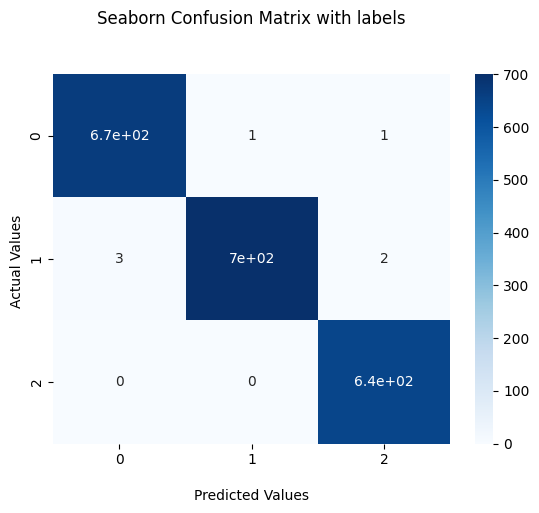

Accuracy: 0.997
Precision: 0.996
Recall: 0.997
F1 Score: 0.997


(0.9965346534653465,
 0.9964894190018567,
 0.9966427701345574,
 0.9965614402670218)

In [ ]:
from tensorflow.keras.models import load_model

best_model = load_model('best_model.h5', custom_objects={'loss_function': custom_loss})

filepath = "/content/drive/MyDrive/BestModel_NBACK.h5"

best_model.save(filepath)

Predictions_Scores(best_model, [eeg_test, nirs_test], labels_test)

In [ ]:
best_model = load_model('/content/drive/MyDrive/BestModel_Dataset2.h5', custom_objects={'loss_function': custom_loss})
Predictions_Scores(best_model, [eeg_test, nirs_test], labels_test)

ValueError: Unknown loss function: 'custom_loss'. Please ensure you are using a `keras.utils.custom_object_scope` and that this object is included in the scope. See https://www.tensorflow.org/guide/keras/save_and_serialize#registering_the_custom_object for details.

In [ ]:
def Get_Results(Features_EEG_Reshaped, Features_NIRS_Reshaped, LabelsData):

  EEG_augmented_features, augmented_labels = DataAugmentation(Features_EEG_Reshaped, LabelsData)
  EEG_augmented_features = (EEG_augmented_features - np.min(EEG_augmented_features)) / (np.max(EEG_augmented_features) - np.min(EEG_augmented_features))

  NIRS_augmented_features, augmented_labels = DataAugmentation(Features_NIRS_Reshaped, LabelsData)
  NIRS_augmented_features = (NIRS_augmented_features - np.mean(NIRS_augmented_features)) / np.std(NIRS_augmented_features)


  onehot_encoder = OneHotEncoder(sparse=False)
  Labels_Encoded = augmented_labels.reshape(len(augmented_labels), 1)
  Labels_Encoded = onehot_encoder.fit_transform(Labels_Encoded)


  eeg_train, eeg_test, nirs_train, nirs_test, labels_train, labels_test = train_test_split(
      EEG_augmented_features, NIRS_augmented_features, Labels_Encoded, test_size=0.2, random_state=42)

  #CNN Results
  accuracy_cnn, precision_cnn, recall_cnn, f1_score_cnn, history = CNN_EEG_NIRS_Testing(eeg_train, eeg_test, nirs_train, nirs_test, labels_train, labels_test)

  val_acc = history.history['val_accuracy']
  valloss = history.history['val_loss']
  train_acc = history.history['accuracy']
  trainloss = history.history['loss']

  #Plots for accuracy and loss
  plt.figure()
  plt.plot(val_acc, 'g', label='val')
  plt.plot(train_acc, 'b', label='train')
  plt.title('Training and Validation Accuracy')
  plt.xlabel('Epochs')
  plt.ylabel('Accuracy')
  plt.legend()
  plt.show()

  plt.figure()
  plt.plot(valloss, 'g', label='val')
  plt.plot(trainloss, 'b', label='train')
  plt.title('Training and Validation Loss')
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.legend()
  plt.show()


